In [70]:
# 1.2 Dataset Understanding

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

pd.set_option("display.width", 120)

In [71]:
# Load Raw Dataset

DATA_PATH = "diabetic_data.csv"

df = pd.read_csv(
    DATA_PATH,
    na_values=["?"]
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


C:\Users\368435\AppData\Local\Temp\ipykernel_21196\3509576147.py:5: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [72]:
# Dataset dimensions

rows, columns = df.shape

print("Number of rows      :", rows)
print("Number of columns   :", columns)

Number of rows      : 101766
Number of columns   : 50


In [73]:
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

01. encounter_id
02. patient_nbr
03. race
04. gender
05. age
06. weight
07. admission_type_id
08. discharge_disposition_id
09. admission_source_id
10. time_in_hospital
11. payer_code
12. medical_specialty
13. num_lab_procedures
14. num_procedures
15. num_medications
16. number_outpatient
17. number_emergency
18. number_inpatient
19. diag_1
20. diag_2
21. diag_3
22. number_diagnoses
23. max_glu_serum
24. A1Cresult
25. metformin
26. repaglinide
27. nateglinide
28. chlorpropamide
29. glimepiride
30. acetohexamide
31. glipizide
32. glyburide
33. tolbutamide
34. pioglitazone
35. rosiglitazone
36. acarbose
37. miglitol
38. troglitazone
39. tolazamide
40. examide
41. citoglipton
42. insulin
43. glyburide-metformin
44. glipizide-metformin
45. glimepiride-pioglitazone
46. metformin-rosiglitazone
47. metformin-pioglitazone
48. change
49. diabetesMed
50. readmitted


In [74]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [76]:
# Number of unique hospital encounters

unique_encounters = df["encounter_id"].nunique()

print("Total rows       :", len(df))
print("Unique encounters:", unique_encounters)

Total rows       : 101766
Unique encounters: 101766


In [77]:
# Number of unique patients

unique_patients = df["patient_nbr"].nunique()

print("Total encounters:", len(df))
print("Unique patients  :", unique_patients)

Total encounters: 101766
Unique patients  : 71518


In [78]:
# Number of encounters per patient

encounters_per_patient = df["patient_nbr"].value_counts()

print("Patients with exactly 1 encounter:",
      (encounters_per_patient == 1).sum())

print("Patients with more than 1 encounter:",
      (encounters_per_patient > 1).sum())

print("\nMaximum encounters for one patient:",
      encounters_per_patient.max())

Patients with exactly 1 encounter: 54745
Patients with more than 1 encounter: 16773

Maximum encounters for one patient: 40


In [79]:
# Show the distribution of number of encounters per patient

encounters_per_patient.value_counts().sort_index()

count
1     54745
2     10434
3      3328
4      1421
5       717
6       346
7       207
8       111
9        70
10       42
11       20
12       19
13       14
14        5
15        9
16        4
17        3
18        6
19        3
20        6
21        1
22        2
23        3
28        1
40        1
Name: count, dtype: int64

In [80]:
# Original readmission target distribution

readmission_counts = df["readmitted"].value_counts()

print(readmission_counts)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [81]:
# Original target distribution in percentage

readmission_percentage = (
    df["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(readmission_percentage)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


In [82]:

# Binary Target Derivation

df["target"] = (
    df["readmitted"] == "<30"
).astype(int)

print("Binary target created successfully.")

Binary target created successfully.


In [83]:
# Binary target counts

target_counts = df["target"].value_counts().sort_index()

print(target_counts)

target
0    90409
1    11357
Name: count, dtype: int64


In [84]:
# Binary target percentages

target_percentage = (
    df["target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(target_percentage)

target
0    88.84
1    11.16
Name: proportion, dtype: float64


In [85]:
# Display data type for every feature

feature_dtypes = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values
})

feature_dtypes

,feature,dtype
0,encounter_id,int64
1,patient_nbr,int64
2,race,str
3,gender,str
4,age,str
5,weight,str
6,admission_type_id,int64
7,discharge_disposition_id,int64
8,admission_source_id,int64
9,time_in_hospital,int64


In [86]:
# Count columns by pandas data type

df.dtypes.value_counts()

str      37
int64    14
Name: count, dtype: int64

In [87]:
# Unique values for every column

unique_summary = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

unique_summary

,feature,dtype,unique_values
0,encounter_id,int64,101766
1,patient_nbr,int64,71518
2,race,str,5
3,gender,str,3
4,age,str,10
5,weight,str,9
6,admission_type_id,int64,8
7,discharge_disposition_id,int64,26
8,admission_source_id,int64,17
9,time_in_hospital,int64,14


In [88]:

# Missing Value Analysis

missing_count = df.isna().sum()

missing_percentage = (
    df.isna().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "feature": df.columns,
    "missing_count": missing_count.values,
    "missing_percentage": missing_percentage.values
})

missing_summary = (
    missing_summary
    .sort_values(
        by="missing_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

missing_summary

,feature,missing_count,missing_percentage
0,weight,98569,96.86
1,max_glu_serum,96420,94.75
2,A1Cresult,84748,83.28
3,medical_specialty,49949,49.08
4,payer_code,40256,39.56
5,race,2273,2.23
6,diag_3,1423,1.40
7,diag_2,358,0.35
8,diag_1,21,0.02
9,patient_nbr,0,0.00


In [89]:
# Features containing missing values

missing_features = missing_summary[
    missing_summary["missing_count"] > 0
]

missing_features

,feature,missing_count,missing_percentage
0,weight,98569,96.86
1,max_glu_serum,96420,94.75
2,A1Cresult,84748,83.28
3,medical_specialty,49949,49.08
4,payer_code,40256,39.56
5,race,2273,2.23
6,diag_3,1423,1.40
7,diag_2,358,0.35
8,diag_1,21,0.02


In [90]:
# Overall missing-value summary

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()

print("Total cells          :", total_cells)
print("Total missing values :", total_missing)
print(
    "Overall missing %    :",
    round((total_missing / total_cells) * 100, 2)
)

Total cells          : 5190066
Total missing values : 374017
Overall missing %    : 7.21


In [91]:
# Top 10 features with highest missing percentage

missing_summary.head(20)

,feature,missing_count,missing_percentage
0,weight,98569,96.86
1,max_glu_serum,96420,94.75
2,A1Cresult,84748,83.28
3,medical_specialty,49949,49.08
4,payer_code,40256,39.56
5,race,2273,2.23
6,diag_3,1423,1.40
7,diag_2,358,0.35
8,diag_1,21,0.02
9,patient_nbr,0,0.00


# 1.3 Exploratory Data Analysis (EDA)

## 1.3.1 Univariate Analysis

In [93]:
# 1.3.1 Univariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Visualization libraries imported successfully.")

Visualization libraries imported successfully.


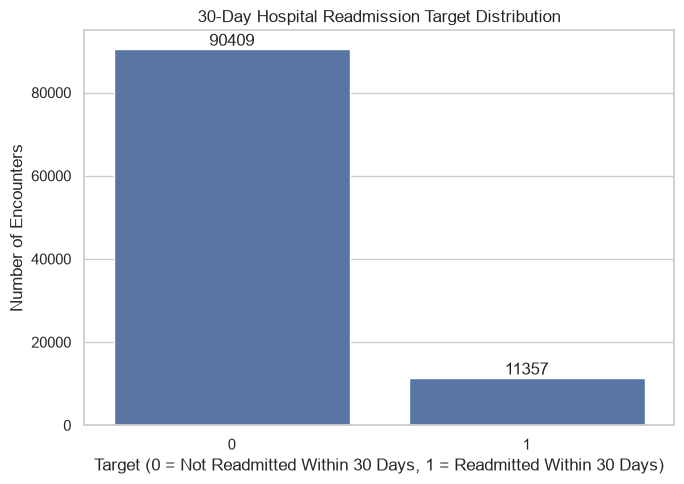

In [94]:
# Target class distribution

target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x="target",
    data=df,
    order=[0, 1]
)

plt.title("30-Day Hospital Readmission Target Distribution")
plt.xlabel("Target (0 = Not Readmitted Within 30 Days, 1 = Readmitted Within 30 Days)")
plt.ylabel("Number of Encounters")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

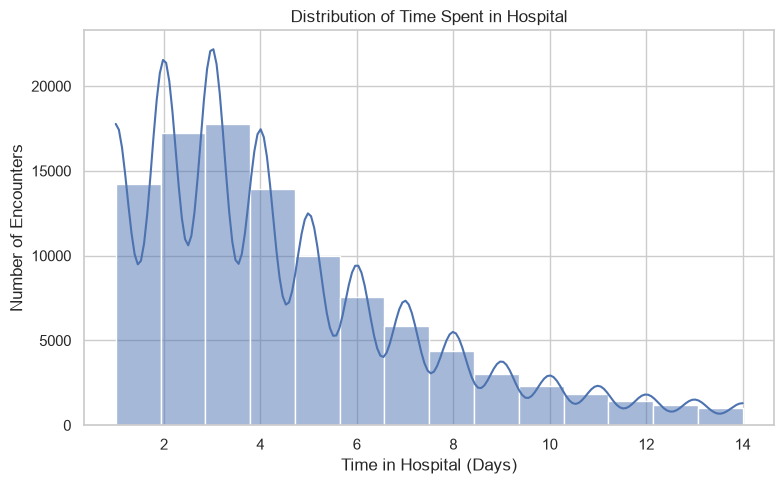

In [95]:
# Distribution of hospital stay duration

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="time_in_hospital",
    bins=14,
    kde=True
)

plt.title("Distribution of Time Spent in Hospital")
plt.xlabel("Time in Hospital (Days)")
plt.ylabel("Number of Encounters")

plt.tight_layout()
plt.show()

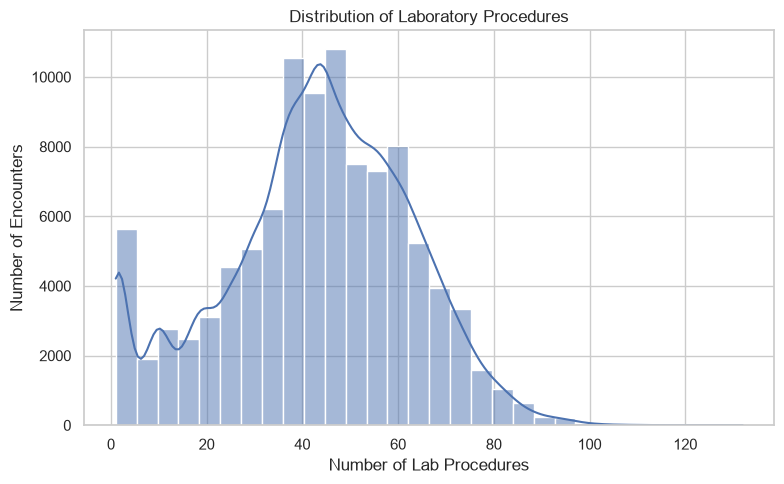

In [96]:
# Distribution of laboratory procedures

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="num_lab_procedures",
    bins=30,
    kde=True
)

plt.title("Distribution of Laboratory Procedures")
plt.xlabel("Number of Lab Procedures")
plt.ylabel("Number of Encounters")

plt.tight_layout()
plt.show()

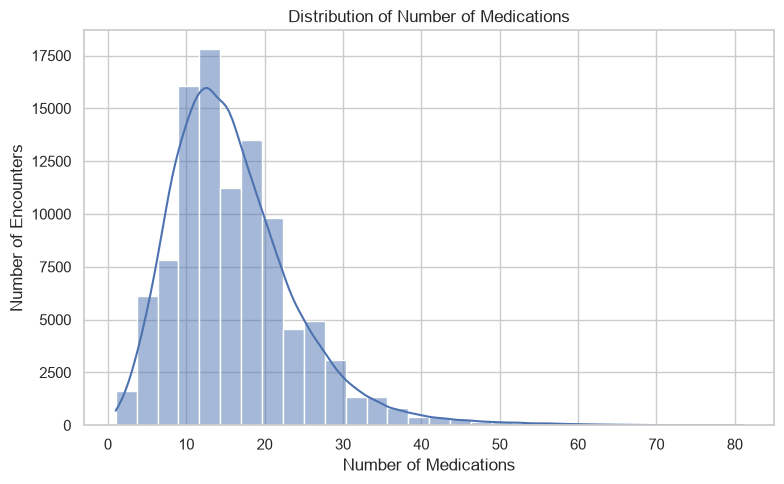

In [97]:
# Distribution of number of medications

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="num_medications",
    bins=30,
    kde=True
)

plt.title("Distribution of Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Number of Encounters")

plt.tight_layout()
plt.show()

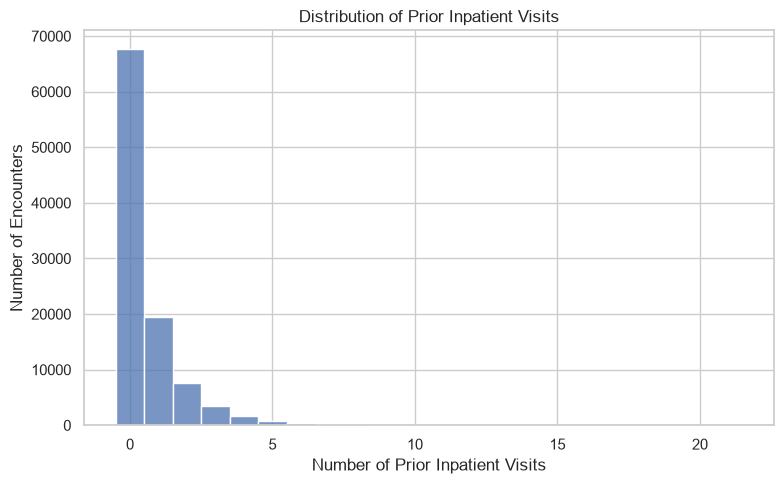

In [98]:
# Distribution of prior inpatient visits

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="number_inpatient",
    discrete=True
)

plt.title("Distribution of Prior Inpatient Visits")
plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("Number of Encounters")

plt.tight_layout()
plt.show()

In [99]:
# Summary statistics for selected numerical variables

numeric_eda_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_inpatient"
]

df[numeric_eda_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0


## 1.3.2 Bivariate Analysis — Prior Inpatient Visits vs 30-Day Readmission

In [100]:
# Calculate 30-day readmission rate by number of prior inpatient visits

readmission_by_inpatient = (
    df.groupby("number_inpatient")["target"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

readmission_by_inpatient.columns = [
    "number_inpatient",
    "total_encounters",
    "readmitted_30_days",
    "readmission_rate"
]

readmission_by_inpatient["readmission_rate_pct"] = (
    readmission_by_inpatient["readmission_rate"] * 100
).round(2)

readmission_by_inpatient

,number_inpatient,total_encounters,readmitted_30_days,readmission_rate,readmission_rate_pct
0,0,67630,5706,0.084371,8.44
1,1,19521,2523,0.129245,12.92
2,2,7566,1319,0.174333,17.43
3,3,3411,692,0.202873,20.29
4,4,1622,383,0.236128,23.61
5,5,812,255,0.314039,31.40
6,6,480,166,0.345833,34.58
7,7,268,95,0.354478,35.45
8,8,151,67,0.443709,44.37
9,9,111,47,0.423423,42.34


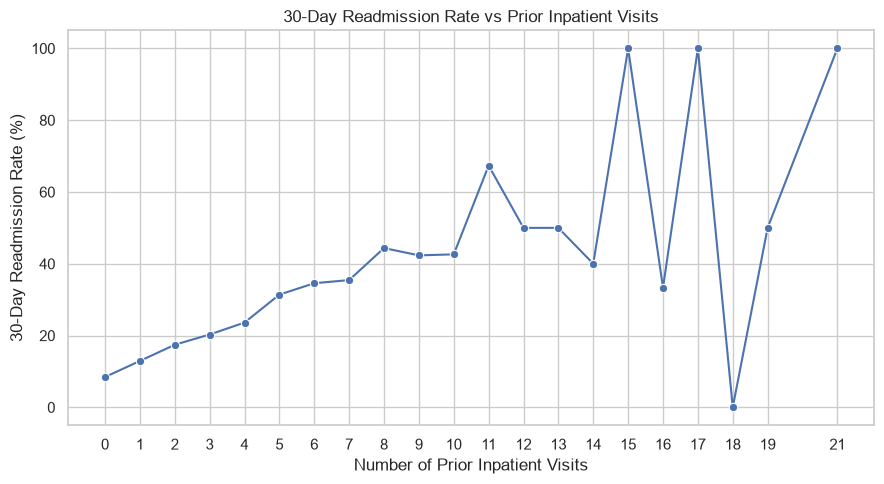

In [101]:
# Plot 30-day readmission rate against prior inpatient visits

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=readmission_by_inpatient,
    x="number_inpatient",
    y="readmission_rate_pct",
    marker="o"
)

plt.title("30-Day Readmission Rate vs Prior Inpatient Visits")
plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("30-Day Readmission Rate (%)")
plt.xticks(
    sorted(df["number_inpatient"].dropna().unique())
)

plt.tight_layout()
plt.show()

In [102]:
# Display sample sizes and readmission rates

readmission_by_inpatient[
    [
        "number_inpatient",
        "total_encounters",
        "readmitted_30_days",
        "readmission_rate_pct"
    ]
]

,number_inpatient,total_encounters,readmitted_30_days,readmission_rate_pct
0,0,67630,5706,8.44
1,1,19521,2523,12.92
2,2,7566,1319,17.43
3,3,3411,692,20.29
4,4,1622,383,23.61
5,5,812,255,31.40
6,6,480,166,34.58
7,7,268,95,35.45
8,8,151,67,44.37
9,9,111,47,42.34


# 1.4 Methodology Design

## 1.4.1 End-to-End MLOps Workflow

The proposed MLOps workflow follows a complete machine-learning lifecycle:

**Validate → Train → Track → Register → Deploy → Monitor → Retrain → Govern**

1. **Validate:** Validate the input dataset and ensure that expected columns, data quality, target definition, and leakage-related constraints are satisfied.

2. **Train:** Prepare the data using leakage-safe preprocessing and train the Logistic Regression baseline and XGBoost advanced model.

3. **Track:** Track model parameters, metrics, model artifacts, and experiment metadata using MLflow.

4. **Register:** Compare the trained models using imbalance-aware evaluation metrics and register the selected model in the MLflow Model Registry. The selected version is promoted to the production alias.

5. **Deploy:** Serve the registered production model through a FastAPI inference service with `/predict` and `/health` endpoints.

6. **Containerise:** Package the inference service using Docker to provide a reproducible runtime environment.

7. **CI/CD:** Use GitHub Actions and pytest to automatically validate the application.

8. **Monitor:** Monitor feature drift using Evidently and prediction drift using Population Stability Index (PSI).

9. **Retrain:** Trigger retraining when predefined drift conditions are reached. The retrained model is evaluated and re-registered before a production promotion decision.

10. **Govern:** Maintain model versions, registry history, production aliases, prediction logs, dependency information, and retraining decisions for reproducibility and traceability.

## 1.4.2 Data Leakage Prevention Strategy

Data leakage is a major risk in this dataset because multiple hospital encounters can belong to the same patient. To prevent leakage, the first encounter per patient will be retained before creating the modelling splits. This prevents the same patient from appearing across training, validation, and test datasets.

The train, validation, and test splits will be created before fitting any preprocessing transformations. All preprocessing operations, including missing-value imputation, scaling, and categorical encoding, will be fitted only on the training data. The fitted transformations will then be applied to the validation and test datasets without refitting.

Feature transformation will be implemented using a leakage-safe scikit-learn Pipeline and ColumnTransformer. This ensures that preprocessing parameters are learned only from the training data and that the same transformations are consistently applied during validation, testing, and inference.

The test set will remain isolated until final model evaluation and will not be used for model selection or preprocessing fitting.

# Stage 2 — Data Preparation

## 2.1 Data Cleaning

In [103]:
df = pd.read_csv(
    DATA_PATH,
    na_values=["?"]
)

C:\Users\368435\AppData\Local\Temp\ipykernel_21196\653703755.py:1: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [104]:
question_mark_count = (df == "?").sum().sum()

print("Remaining '?' values:", question_mark_count)

Remaining '?' values: 0


In [105]:

total_missing = df.isna().sum().sum()

print("Total NaN values:", total_missing)

Total NaN values: 374017


In [106]:
# Check missingness of weight before dropping

weight_missing_pct = df["weight"].isna().mean() * 100

print(f"Missing values in weight: {weight_missing_pct:.2f}%")

Missing values in weight: 96.86%


In [107]:
# Drop weight due to extremely high missingness

df = df.drop(columns=["weight"])

print("'weight' column dropped.")
print("New dataset shape:", df.shape)

'weight' column dropped.
New dataset shape: (101766, 49)


In [108]:
# Identify columns with only one unique non-null value

constant_columns = [
    col
    for col in df.columns
    if df[col].nunique(dropna=True) <= 1
]

print("Constant / zero-variance columns:")
print(constant_columns)

Constant / zero-variance columns:
['examide', 'citoglipton']


In [109]:
# Inspect constant columns

for col in constant_columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: examide
examide
No    101766
Name: count, dtype: int64

Column: citoglipton
citoglipton
No    101766
Name: count, dtype: int64


In [110]:
# Drop constant / zero-variance columns

if constant_columns:
    df = df.drop(columns=constant_columns)

print("Constant columns dropped:", constant_columns)
print("Current dataset shape:", df.shape)

Constant columns dropped: ['examide', 'citoglipton']
Current dataset shape: (101766, 47)


In [111]:
# Summary of columns removed during 2.1.1

removed_columns_2_1_1 = ["weight"] + constant_columns

print("Columns removed in 2.1.1:")
for col in removed_columns_2_1_1:
    print("-", col)

Columns removed in 2.1.1:
- weight
- examide
- citoglipton


In [112]:
# Verify current dataset structure

print("Current dataset shape:", df.shape)
print("Remaining columns:", len(df.columns))
# Verify that removed columns no longer exist

print(
    "Removed columns still present:",
    [
        col
        for col in removed_columns_2_1_1
        if col in df.columns
    ]
)

Current dataset shape: (101766, 47)
Remaining columns: 47
Removed columns still present: []
